# Classical EDA

A first descriptive pass over the dataset that powers
`scripts/02_train_model.py`. We work with `data/listings_raw.parquet` (git ignored),
which is the local mirror of the BigQuery table.

The goal of this notebook is not to to surface
the shape of the data: distributions, missingness, summary statistics,
and a few targeted bivariate cuts. Spatial and temporal exploration
live in the companion notebooks to limit the reach.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "listings_raw.parquet"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ACCENT = "#4f46e5"

## 1. Load and basic shape

In [2]:
df = pd.read_parquet(DATA)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 172,562 rows × 45 columns


,id,isNewlyBuilt,isNotarySale,publication_creationDate,bathroomCount,bedroomCount,constructionYear,facadeCount,hasDoubleGlazing,hasHeatPump,hasPhotovoltaicPanels,hasThermicPanels,heatingType,hasFireplace,gardenOrientation,hasAttic,hasBasement,hasDiningRoom,hasGarden,hasLaundryRoom,hasLift,hasLivingRoom,hasSauna,hasSecureAccessAlarm,hasSwimmingPool,hasTerrace,kitchenType,latitude,longitude,postalCode,netHabitableSurface,parkingCount,roomCount,showerRoomCount,subType,terraceOrientation,terraceSurface,toiletCount,publication_lastModificationDate,epcScore,price,riskMonetaryPoverty,medianSellPrice,totalPopulation,url
0,10071043,0,0,2023-08-05 16:59:00.960,1,2,1989,1,1,0,0,0,GAS,0,Unknown,0,0,0,0,0,0,1,0,0,0,0,Unknown,51.35,3.29,8300,55,0,1,0,APARTMENT,Unknown,0,1,2024-12-07 15:00:07.931,B,585000,85,770000,32415,https://www.immoweb.be/en/classified/APARTMENT...
1,10256317,0,0,2022-11-29 19:07:47.000,1,2,1981,3,1,0,0,0,GAS,0,Unknown,0,1,0,0,0,1,1,0,0,0,1,Unknown,51.22,2.89,8400,76,0,2,0,APARTMENT,Unknown,16,1,2024-08-06 16:14:24.821,C,249000,111,295000,72817,https://www.immoweb.be/en/classified/APARTMENT...
2,10620577,0,0,2023-06-08 10:39:08.313,1,4,1962,3,1,0,0,0,GAS,1,SOUTH,0,0,0,1,0,0,1,0,0,0,1,INSTALLED,51.21,2.87,8400,240,2,0,0,TOWN_HOUSE,SOUTH,12,2,2024-09-02 17:13:45.083,F,280000,111,295000,72817,https://www.immoweb.be/en/classified/TOWN_HOUS...


In [ ]:
# How many of each dtype family: useful before designing the rest of the EDA.
df.dtypes.value_counts()

Int64             34
object             7
datetime64[us]     2
float64            2
Name: count, dtype: int64

## 2. Target variable: price

Asking prices are heavy-tailed. We always look at both the raw and
log-scale view: the raw histogram exposes outliers, the log scale
exposes structure.

In [4]:
price = df["price"].dropna()
price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0).astype("Int64")

count      172562
mean       464065
std        397735
min         10000
1%         115000
5%         169900
25%        275000
50%        375000
75%        524000
95%        995000
99%       1955000
max      10000000
Name: price, dtype: Int64

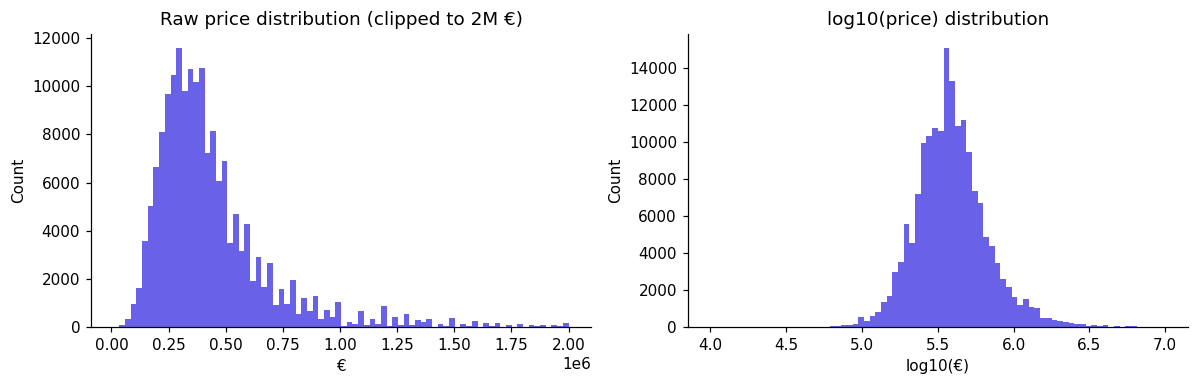

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(price[price < 2_000_000], bins=80, color=ACCENT, alpha=0.85)
axes[0].set_title("Raw price distribution (clipped to 2M €)")
axes[0].set_xlabel("€"); axes[0].set_ylabel("Count")
axes[1].hist(np.log10(price[price > 0]), bins=80, color=ACCENT, alpha=0.85)
axes[1].set_title("log10(price) distribution")
axes[1].set_xlabel("log10(€)"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

### 2.1 The production cleaning rule

We should filters listings to the [20 000, 5 000 000]
euro range. Below that we are looking at parking spots, encoding errors,
and life-annuity prefixes. Above that we are looking at the long right
tail where the model has too few comparables to learn from.

In [6]:
n_low = (price < 20_000).sum()
n_high = (price > 5_000_000).sum()
print(f"Below 20k     : {n_low:,} listings ({n_low / len(price):.2%})")
print(f"Above 5M      : {n_high:,} listings ({n_high / len(price):.2%})")
print(f"Total dropped : {n_low + n_high:,}")

df_clean = df[df["price"].between(20_000, 5_000_000)].copy()
print(f"\nClean subset : {len(df_clean):,} rows")

Below 20k     : 4 listings (0.00%)
Above 5M      : 178 listings (0.10%)
Total dropped : 182

Clean subset : 172,380 rows


## 3. Missingness

Which columns are filled often enough to be useful? The training
script discards anything below roughly fifteen percent coverage as
"too sparse to impute well", which is a heuristic, not a hard rule.

In [7]:
miss = (df_clean.isna().mean().sort_values(ascending=False) * 100).round(1)
miss = miss[miss > 0]
miss.to_frame("pct_missing")

,pct_missing
medianSellPrice,1.60


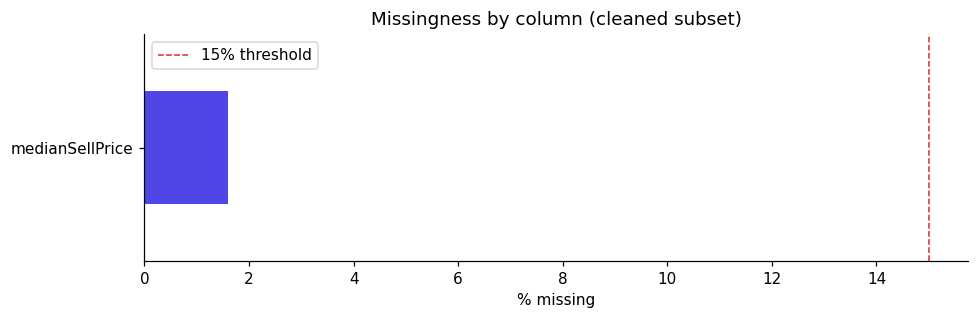

In [8]:
if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(miss) * 0.25)))
    miss.sort_values().plot.barh(ax=ax, color=ACCENT)
    ax.axvline(15, color="#dc2626", linestyle="--", linewidth=1, label="15% threshold")
    ax.set_xlabel("% missing")
    ax.set_title("Missingness by column (cleaned subset)")
    ax.legend()
    plt.tight_layout(); plt.show()

## 4. Numeric features

A grid of histograms for the numeric columns we keep in the model. The
values are clipped to the 99th percentile so the long right tails do
not collapse the bulk of the distribution against the y-axis.

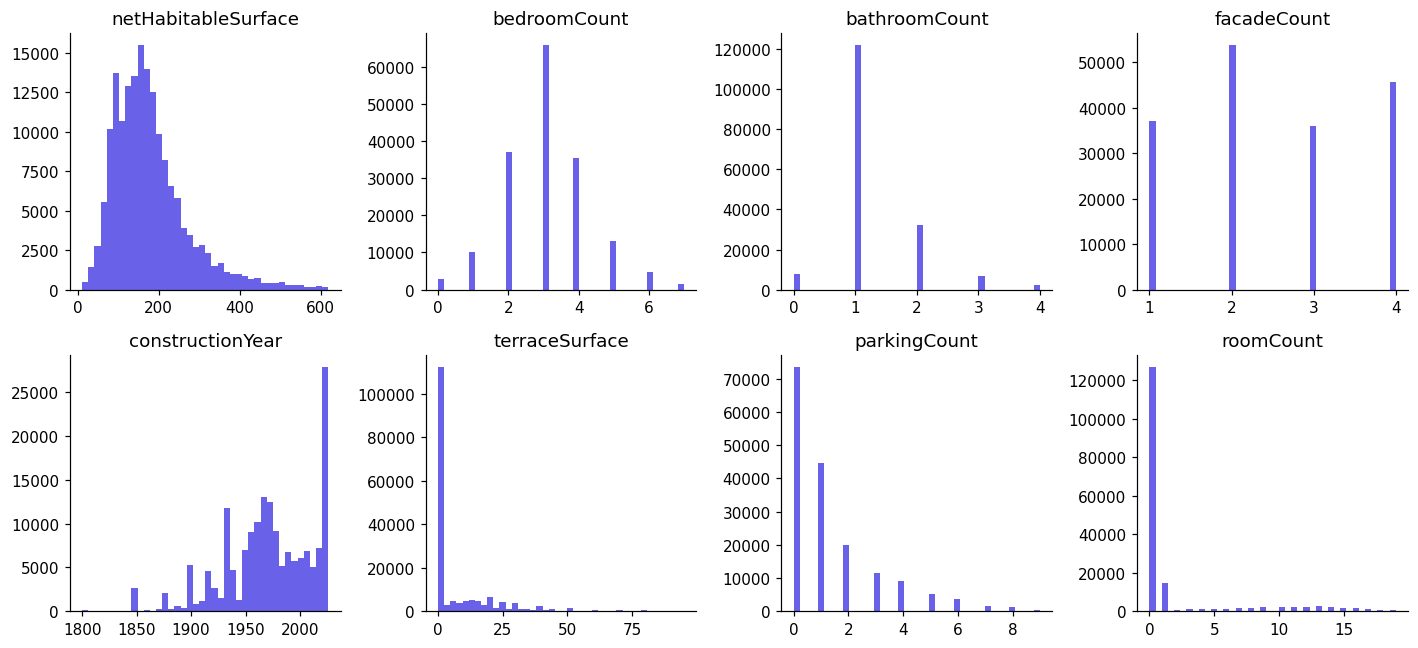

In [9]:
num_cols = [
    "netHabitableSurface", "bedroomCount", "bathroomCount", "facadeCount",
    "constructionYear", "terraceSurface", "parkingCount", "roomCount",
]

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, col in zip(axes.flat, num_cols):
    s = df_clean[col].dropna()
    if s.empty:
        ax.set_title(f"{col} (empty)")
        continue
    if col == "constructionYear":
        s = s[s.between(1800, 2026)]
    else:
        p99 = s.quantile(0.99)
        s = s[s <= p99]
    ax.hist(s, bins=40, color=ACCENT, alpha=0.85)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 5. Categorical features

For each categorical, two questions: how many distinct values, and
which values dominate. We add a derived `province` column (first digit
of the postal code) because it gives a broader geographic split than
the full postal code (better to map the digit to the province name).

In [10]:
df_clean["postalCode_str"] = df_clean["postalCode"].astype("string").str.zfill(4)
df_clean["province"] = df_clean["postalCode_str"].str[0]

cat_cols = ["subType", "kitchenType", "heatingType", "epcScore", "province"]
for c in cat_cols:
    print(f"\n=== {c} (cardinality {df_clean[c].nunique(dropna=True)}) ===")
    print(df_clean[c].value_counts(dropna=False).head(10).to_string())


=== subType (cardinality 23) ===
subType
HOUSE                   101487
APARTMENT                32695
VILLA                    12660
APARTMENT_BLOCK           4056
MIXED_USE_BUILDING        3748
GROUND_FLOOR              2606
DUPLEX                    2203
PENTHOUSE                 1754
BUNGALOW                  1731
EXCEPTIONAL_PROPERTY      1730

=== kitchenType (cardinality 9) ===
kitchenType
Unknown               60274
INSTALLED             55638
HYPER_EQUIPPED        29666
SEMI_EQUIPPED         17498
NOT_INSTALLED          5737
USA_INSTALLED          1668
USA_HYPER_EQUIPPED     1527
USA_SEMI_EQUIPPED       242
USA_UNINSTALLED         130

=== heatingType (cardinality 8) ===
heatingType
GAS         86734
Unknown     50165
FUELOIL     24773
ELECTRIC     8539
PELLET       1532
WOOD          446
SOLAR         104
CARBON         87

=== epcScore (cardinality 10) ===
epcScore
B          33356
C          31366
D          24143
F          22577
A          19726
Unknown    17843
E       

### 5.1 Median price by category

Where each category sits in the price distribution. We use median
rather than mean because the long right tail of prices badly distorts
means within small categories.

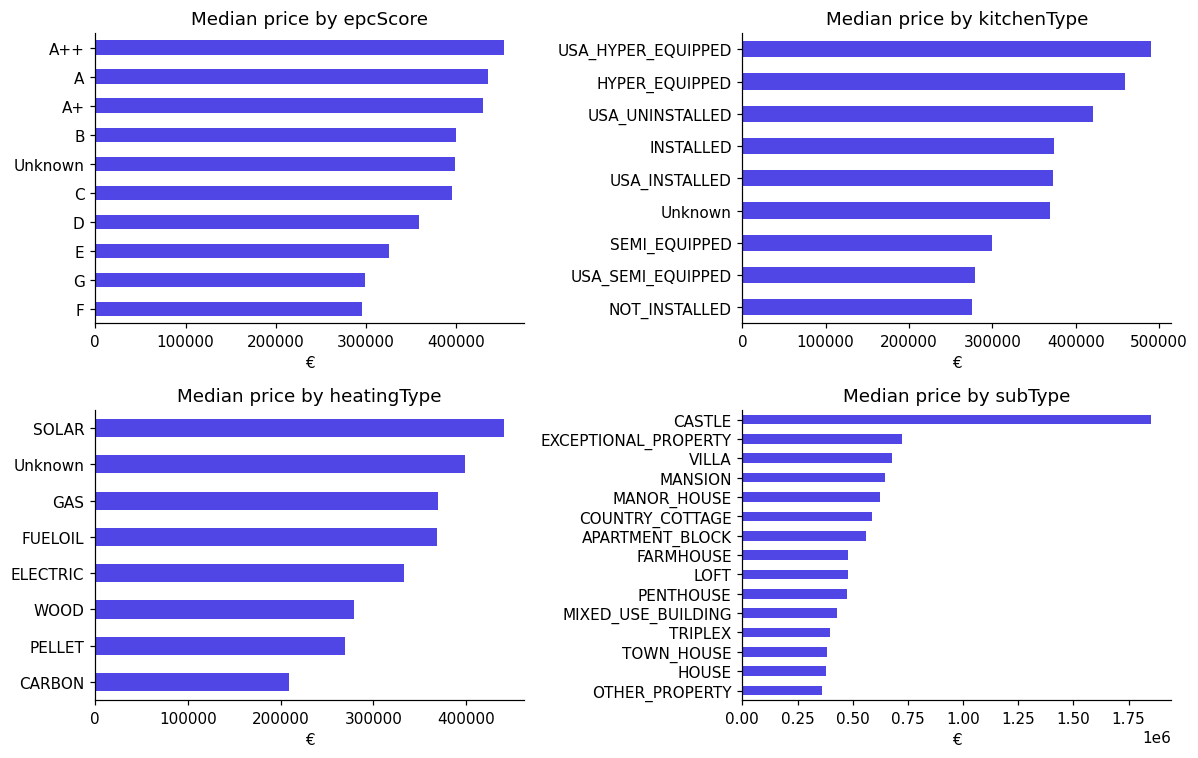

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flat, ["epcScore", "kitchenType", "heatingType", "subType"]):
    g = df_clean.groupby(c, observed=True)["price"].median().sort_values()
    g.tail(15).plot.barh(ax=ax, color=ACCENT)
    ax.set_title(f"Median price by {c}")
    ax.set_xlabel("€"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 6. Bivariate cuts

The three relationships every real-estate analyst checks first:
price vs surface, price vs construction year, price vs bedrooms.

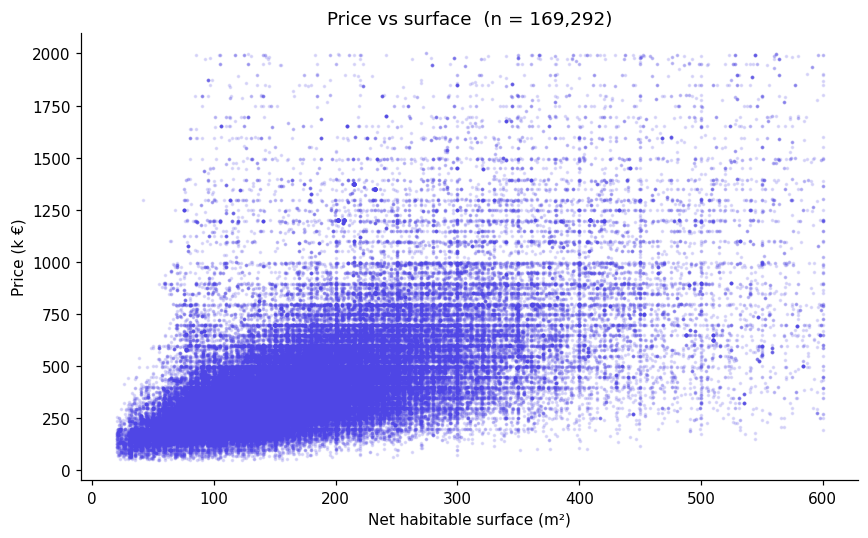

In [12]:
sub = df_clean.dropna(subset=["netHabitableSurface", "price"])
sub = sub[sub["netHabitableSurface"].between(20, 600) & sub["price"].between(50_000, 2_000_000)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sub["netHabitableSurface"], sub["price"] / 1000, s=2, alpha=0.15, color=ACCENT)
ax.set_xlabel("Net habitable surface (m²)")
ax.set_ylabel("Price (k €)")
ax.set_title(f"Price vs surface  (n = {len(sub):,})")
plt.tight_layout(); plt.show()

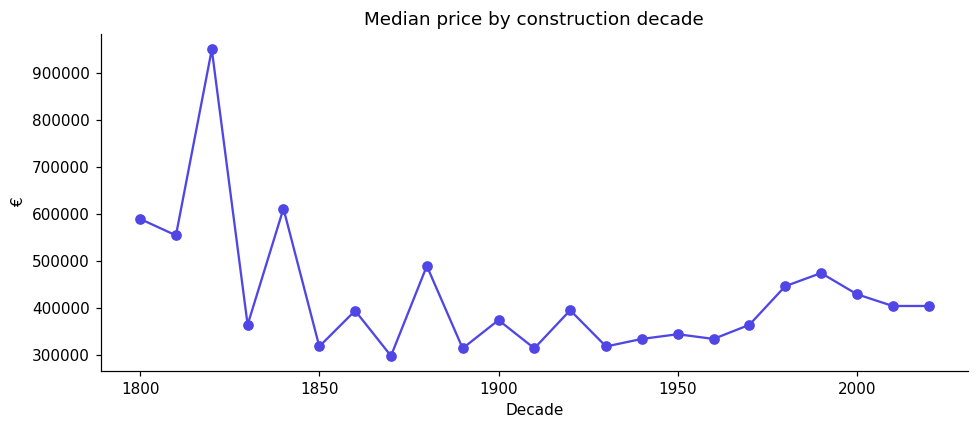

In [13]:
sub = df_clean.dropna(subset=["constructionYear", "price"])
sub = sub[sub["constructionYear"].between(1800, 2026)]
g = sub.groupby((sub["constructionYear"] // 10) * 10)["price"].median()
fig, ax = plt.subplots(figsize=(9, 4))
g.plot(ax=ax, marker="o", color=ACCENT)
ax.set_title("Median price by construction decade")
ax.set_xlabel("Decade"); ax.set_ylabel("€")
plt.tight_layout(); plt.show()

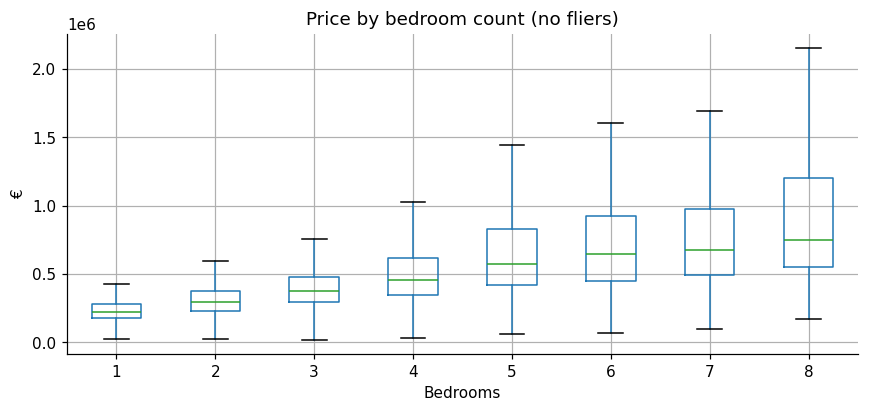

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sub = df_clean.dropna(subset=["bedroomCount", "price"])
sub = sub[sub["bedroomCount"].between(1, 8)]
sub.boxplot(column="price", by="bedroomCount", ax=ax, showfliers=False)
ax.set_title("Price by bedroom count (no fliers)")
ax.set_xlabel("Bedrooms"); ax.set_ylabel("€")
plt.suptitle("")
plt.tight_layout(); plt.show()

### 6.1 EPC score vs price

EPC is an ordered category (A best, G worst). We render it as a sorted
bar chart so the gradient is visible.

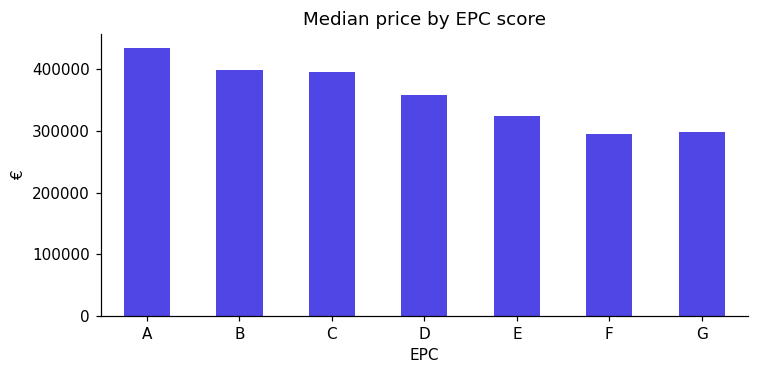

In [15]:
order = ["A", "B", "C", "D", "E", "F", "G"]
g = df_clean[df_clean["epcScore"].isin(order)].groupby("epcScore", observed=True)["price"].median()
g = g.reindex(order).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
g.plot.bar(ax=ax, color=ACCENT)
ax.set_title("Median price by EPC score")
ax.set_xlabel("EPC"); ax.set_ylabel("€")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 7. Geographic split (no map)

The first digit of the Belgian postal code identifies a coarse region.
A non-spatial breakdown by province is enough to catch gross
geographic effects; the spatial-EDA notebook will go further.

In [16]:
prov_label = {
    "1": "1xxx — Brussels region",
    "2": "2xxx — Antwerp",
    "3": "3xxx — Flemish Brabant + Limburg",
    "4": "4xxx — Liège",
    "5": "5xxx — Namur",
    "6": "6xxx — Hainaut south + Luxembourg",
    "7": "7xxx — Hainaut north",
    "8": "8xxx — West Flanders",
    "9": "9xxx — East Flanders",
}
df_clean["province_label"] = df_clean["province"].map(prov_label)
g = df_clean.groupby("province_label").agg(
    n=("price", "size"),
    median_price=("price", "median"),
    median_surface=("netHabitableSurface", "median"),
).sort_values("median_price")
g

,n,median_price,median_surface
province_label,,,
4xxx — Liège,10574,"269,000.00",148.00
7xxx — Hainaut north,3151,"289,000.00",165.00
6xxx — Hainaut south + Luxembourg,5737,"290,000.00",162.00
5xxx — Namur,2740,"299,000.00",156.00
8xxx — West Flanders,26186,"350,000.00",150.00
2xxx — Antwerp,41555,"385,000.00",162.00
9xxx — East Flanders,33976,"385,000.00",165.00
3xxx — Flemish Brabant + Limburg,20202,"389,000.00",178.00
1xxx — Brussels region,28259,"450,000.00",163.00


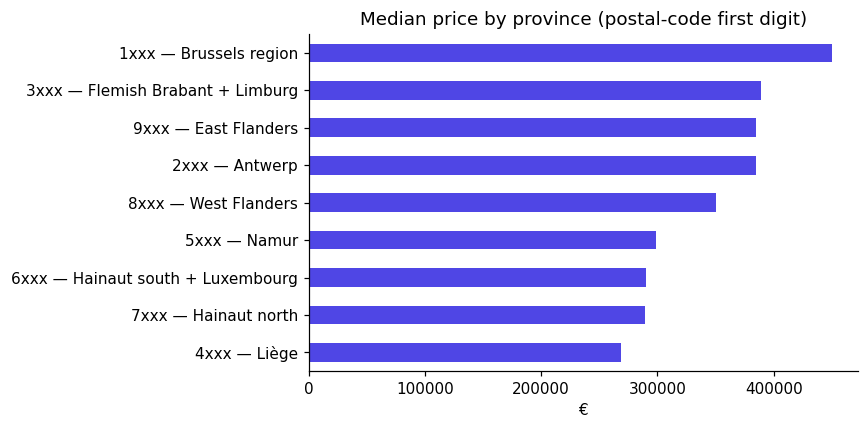

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
g["median_price"].sort_values().plot.barh(ax=ax, color=ACCENT)
ax.set_title("Median price by province (postal-code first digit)")
ax.set_xlabel("€"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 8. Engineered features (quick peek)

In [18]:
NOW_YEAR = 2026
df_clean["property_age"] = (NOW_YEAR - df_clean["constructionYear"]).clip(lower=0, upper=200)
df_clean["construction_decade"] = (df_clean["constructionYear"] // 10 * 10).clip(lower=1800, upper=NOW_YEAR)
df_clean["surface_per_bedroom"] = df_clean["netHabitableSurface"] / df_clean["bedroomCount"].replace(0, np.nan)

print("property_age summary:")
print(df_clean["property_age"].describe(percentiles=[0.05, 0.5, 0.95]).round(1).to_string())
print("\nsurface_per_bedroom summary:")
print(df_clean["surface_per_bedroom"].describe(percentiles=[0.05, 0.5, 0.95]).round(1).to_string())

property_age summary:
count   172,380.00
mean         54.80
std          41.40
min           0.00
5%            2.00
50%          54.00
95%         127.00
max         200.00

surface_per_bedroom summary:
count   169,455.00
mean         58.40
std          26.20
min           3.70
5%           34.00
50%          53.00
95%         100.00
max       1,100.00


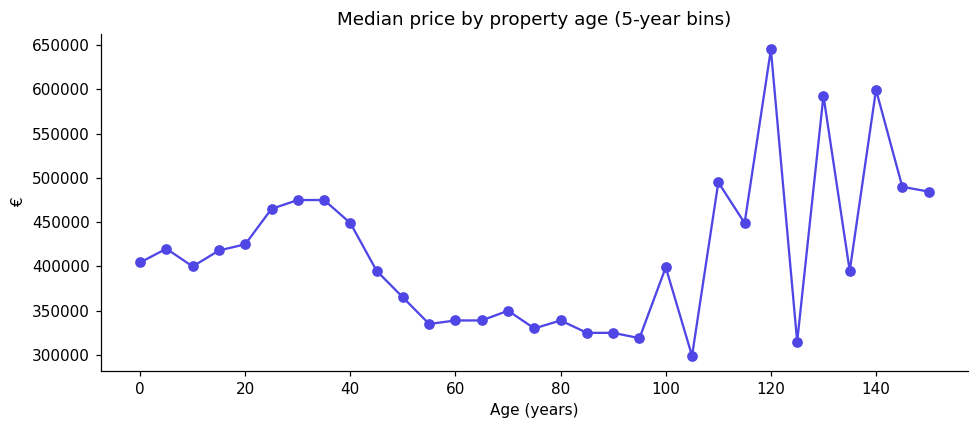

In [19]:
sub = df_clean.dropna(subset=["property_age", "price"])
sub = sub[sub["property_age"].between(0, 150)]
g = sub.groupby((sub["property_age"] // 5) * 5)["price"].median()

fig, ax = plt.subplots(figsize=(9, 4))
g.plot(ax=ax, marker="o", color=ACCENT)
ax.set_title("Median price by property age (5-year bins)")
ax.set_xlabel("Age (years)"); ax.set_ylabel("€")
plt.tight_layout(); plt.show()

## 9. Correlation heatmap (numeric only)

Pearson correlations between log price and the model's numeric
features. We use log price because price itself is heavy-tailed and
the linear correlation is not a good summary in that case.

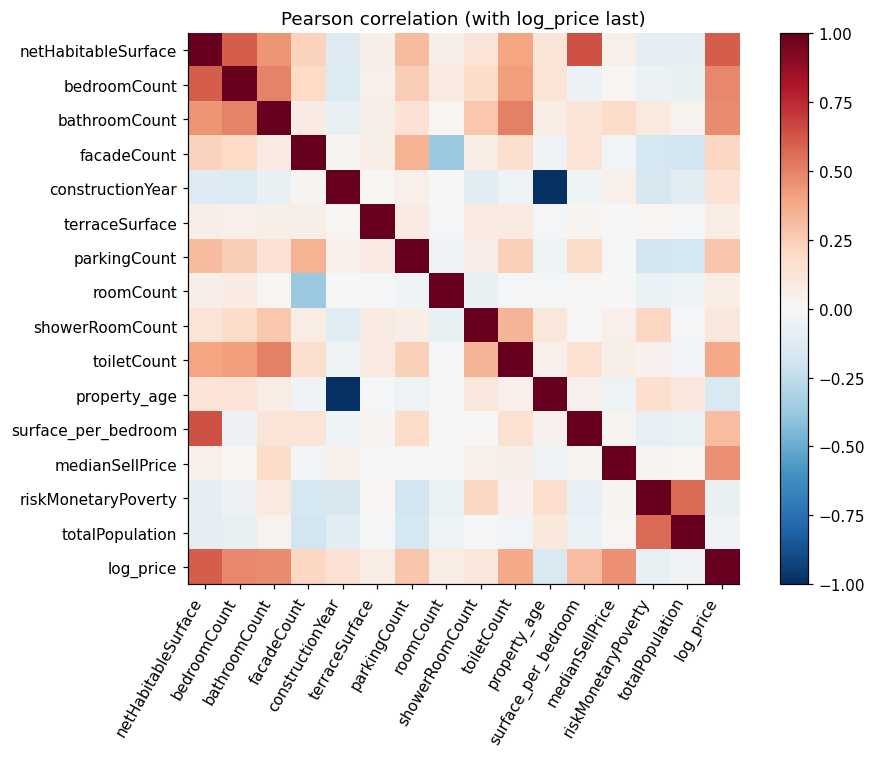

In [20]:
num_features = [
    "netHabitableSurface", "bedroomCount", "bathroomCount", "facadeCount",
    "constructionYear", "terraceSurface", "parkingCount", "roomCount",
    "showerRoomCount", "toiletCount", "property_age", "surface_per_bedroom",
    "medianSellPrice", "riskMonetaryPoverty", "totalPopulation",
]
num_features = [c for c in num_features if c in df_clean.columns]

X = df_clean[num_features + ["price"]].copy()
X["log_price"] = np.log1p(X["price"])
X = X.drop(columns=["price"])
corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Pearson correlation (with log_price last)")
plt.tight_layout(); plt.show()

In [21]:
# Top features by absolute correlation with log price.
corr["log_price"].drop("log_price").abs().sort_values(ascending=False).head(15).round(3)

netHabitableSurface   0.60
bedroomCount          0.48
bathroomCount         0.47
medianSellPrice       0.46
toiletCount           0.38
surface_per_bedroom   0.31
parkingCount          0.28
facadeCount           0.20
property_age          0.15
constructionYear      0.15
showerRoomCount       0.11
riskMonetaryPoverty   0.08
roomCount             0.07
terraceSurface        0.07
totalPopulation       0.04
Name: log_price, dtype: float64

## 10. Remarks

1. **Price is heavy-tailed.** A log transformation is necessary before
   any linear analysis or symmetric loss function.
2. **Missingness is concentrated in a few columns.**.
3. **Surface dominates the price signal.** No surprise. Surface and
   bedroom count together explain a large share of the variance,
   even before any spatial enrichment.
4. **Construction year shows the expected non-monotonic shape.**
   Pre-1900 stock and post-2010 construction both command a premium,
   the mid-century cohort (1960s and 1970s) is where prices drop
   relative to neighbouring decades.
5. **EPC has a clean ordered effect.** Median price decreases
   monotonically from A to G, which is the kind of clean signal the
   model picks up easily.
6. **Provincial split shows a roughly two-to-one price ratio.** The
   most expensive postal-code-first-digit area is between two and
   three times more expensive than the cheapest.
7. **Several features have non-trivial correlations with log price**
   beyond the obvious ones: `medianSellPrice`, `surface_per_bedroom`,
   and `property_age` all carry independent signal worth examining.